# README

This notebook is organized for quick function verification:

1. **First cell**: verifies `rgb_to_hsi`
2. **Second cell**: verifies `build_psf`

Run the cells in order to confirm both components behave as expected.

Wavelengths: (32,) 400.0 → 710.0 nm


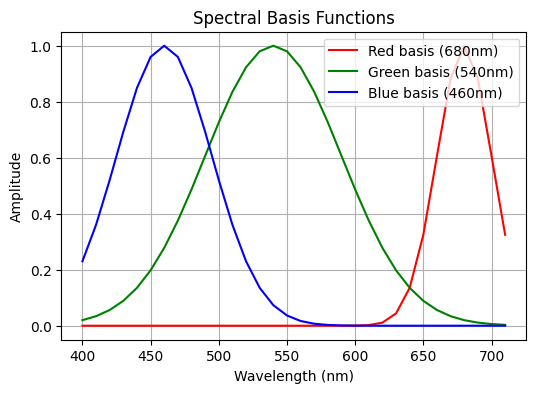

Spectral shape: (512, 512, 32)
HSI saved: ../data/butterfly_hsi.pt, shape=(32, 512, 512), min=0.0000, max=1.0000


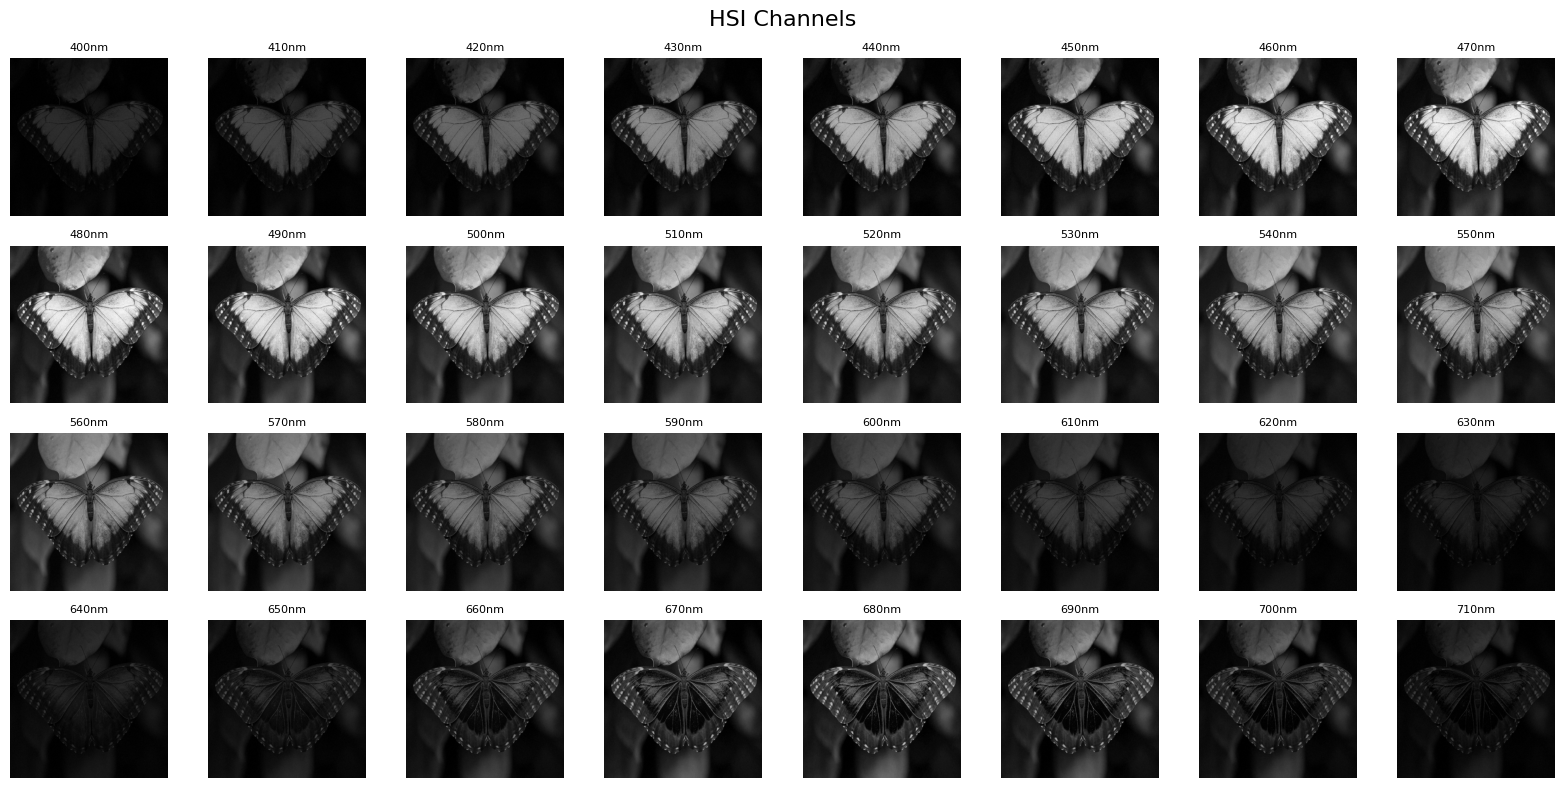

In [16]:
import torch
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
import math

# ── Config / Hardcoded values ─────────────────────────────────────────────────
IMG_PATH       = '../data/butterfly.png'
OUT_PATH       = '../data/butterfly_hsi.pt'
IMG_SIZE       = 512
BANDS          = 32
START_LAMBDA   = 400  # nm
END_LAMBDA     = 710  # nm
NOISE_LEVEL    = 0.01
GRID_COLS      = 8

# Spectral basis parameters
BASIS_PARAMS = {
    "r": {"mu": 680, "sigma": 20},
    "g": {"mu": 540, "sigma": 50},
    "b": {"mu": 460, "sigma": 35}
}

# ── Load + preprocess ─────────────────────────────────────────────────────────
img = Image.open(IMG_PATH).convert("RGB")
img = img.resize((IMG_SIZE, IMG_SIZE), resample=Image.BICUBIC)
rgb = np.asarray(img).astype(np.float32) / 255.0  # [H,W,3]

H, W, _ = rgb.shape
B = BANDS

# ── Wavelength grid ───────────────────────────────────────────────────────────
wavelengths = np.linspace(START_LAMBDA, END_LAMBDA, B)
print("Wavelengths:", wavelengths.shape, wavelengths[0], "→", wavelengths[-1], "nm")

# ── Spectral basis ────────────────────────────────────────────────────────────
def gaussian(wl, mu, sigma):
    return np.exp(-0.5 * ((wl - mu) / sigma) ** 2)

basis_r = gaussian(wavelengths, BASIS_PARAMS["r"]["mu"], BASIS_PARAMS["r"]["sigma"])
basis_g = gaussian(wavelengths, BASIS_PARAMS["g"]["mu"], BASIS_PARAMS["g"]["sigma"])
basis_b = gaussian(wavelengths, BASIS_PARAMS["b"]["mu"], BASIS_PARAMS["b"]["sigma"])
basis = np.stack([basis_r, basis_g, basis_b], axis=0)
basis /= (basis.max(axis=1, keepdims=True) + 1e-8)

# ── Plot spectral basis ───────────────────────────────────────────────────────
plt.figure(figsize=(6,4))
plt.plot(wavelengths, basis_r, color="red", label=f"Red basis ({BASIS_PARAMS['r']['mu']}nm)")
plt.plot(wavelengths, basis_g, color="green", label=f"Green basis ({BASIS_PARAMS['g']['mu']}nm)")
plt.plot(wavelengths, basis_b, color="blue", label=f"Blue basis ({BASIS_PARAMS['b']['mu']}nm)")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Amplitude")
plt.title("Spectral Basis Functions")
plt.legend()
plt.grid(True)
plt.show()

# ── Convert RGB → spectrum ───────────────────────────────────────────────────
spectral = np.tensordot(rgb, basis, axes=([2],[0]))
spectral /= spectral.max()
print("Spectral shape:", spectral.shape)

# ── Add spectral noise ───────────────────────────────────────────────────────
spectral += NOISE_LEVEL * np.random.randn(H, W, B)
spectral = np.clip(spectral, 0.0, 1.0)

# ── Convert to tensor (C,H,W) ───────────────────────────────────────────────
hsi = torch.from_numpy(spectral).permute(2,0,1).contiguous()

# ── Save HSI ────────────────────────────────────────────────────────────────
os.makedirs(os.path.dirname(OUT_PATH) or ".", exist_ok=True)
torch.save(hsi, OUT_PATH)
print(f"HSI saved: {OUT_PATH}, shape={tuple(hsi.shape)}, min={hsi.min():.4f}, max={hsi.max():.4f}")

# ── Visualize HSI channels ───────────────────────────────────────────────────
x = torch.load(OUT_PATH, weights_only=True)
C, H, W = x.shape
rows = math.ceil(C / GRID_COLS)

plt.figure(figsize=(GRID_COLS*2, rows*2))
for i in range(C):
    plt.subplot(rows, GRID_COLS, i+1)
    plt.imshow(x[i].numpy(), cmap='gray', vmin=0, vmax=1)
    plt.title(f"{int(wavelengths[i])}nm", fontsize=8)
    plt.axis('off')
plt.suptitle("HSI Channels", fontsize=16)
plt.tight_layout()
plt.show()

Building PSF tensor...
tensor([0.0080, 0.0101, 0.0126, 0.0154, 0.0186, 0.0221, 0.0258, 0.0297, 0.0337,
        0.0376, 0.0412, 0.0446, 0.0475, 0.0497, 0.0513, 0.0521, 0.0521, 0.0513,
        0.0497, 0.0475, 0.0446, 0.0412, 0.0376, 0.0337, 0.0297, 0.0258, 0.0221,
        0.0186, 0.0154, 0.0126, 0.0101, 0.0080])
Peak value : 0.00995


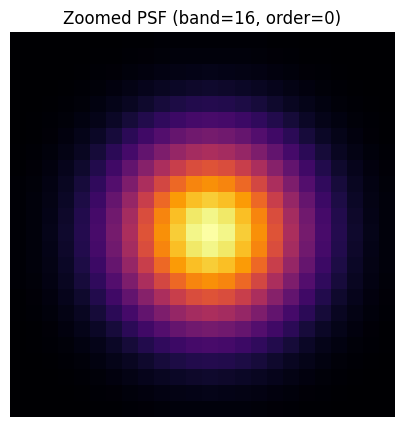

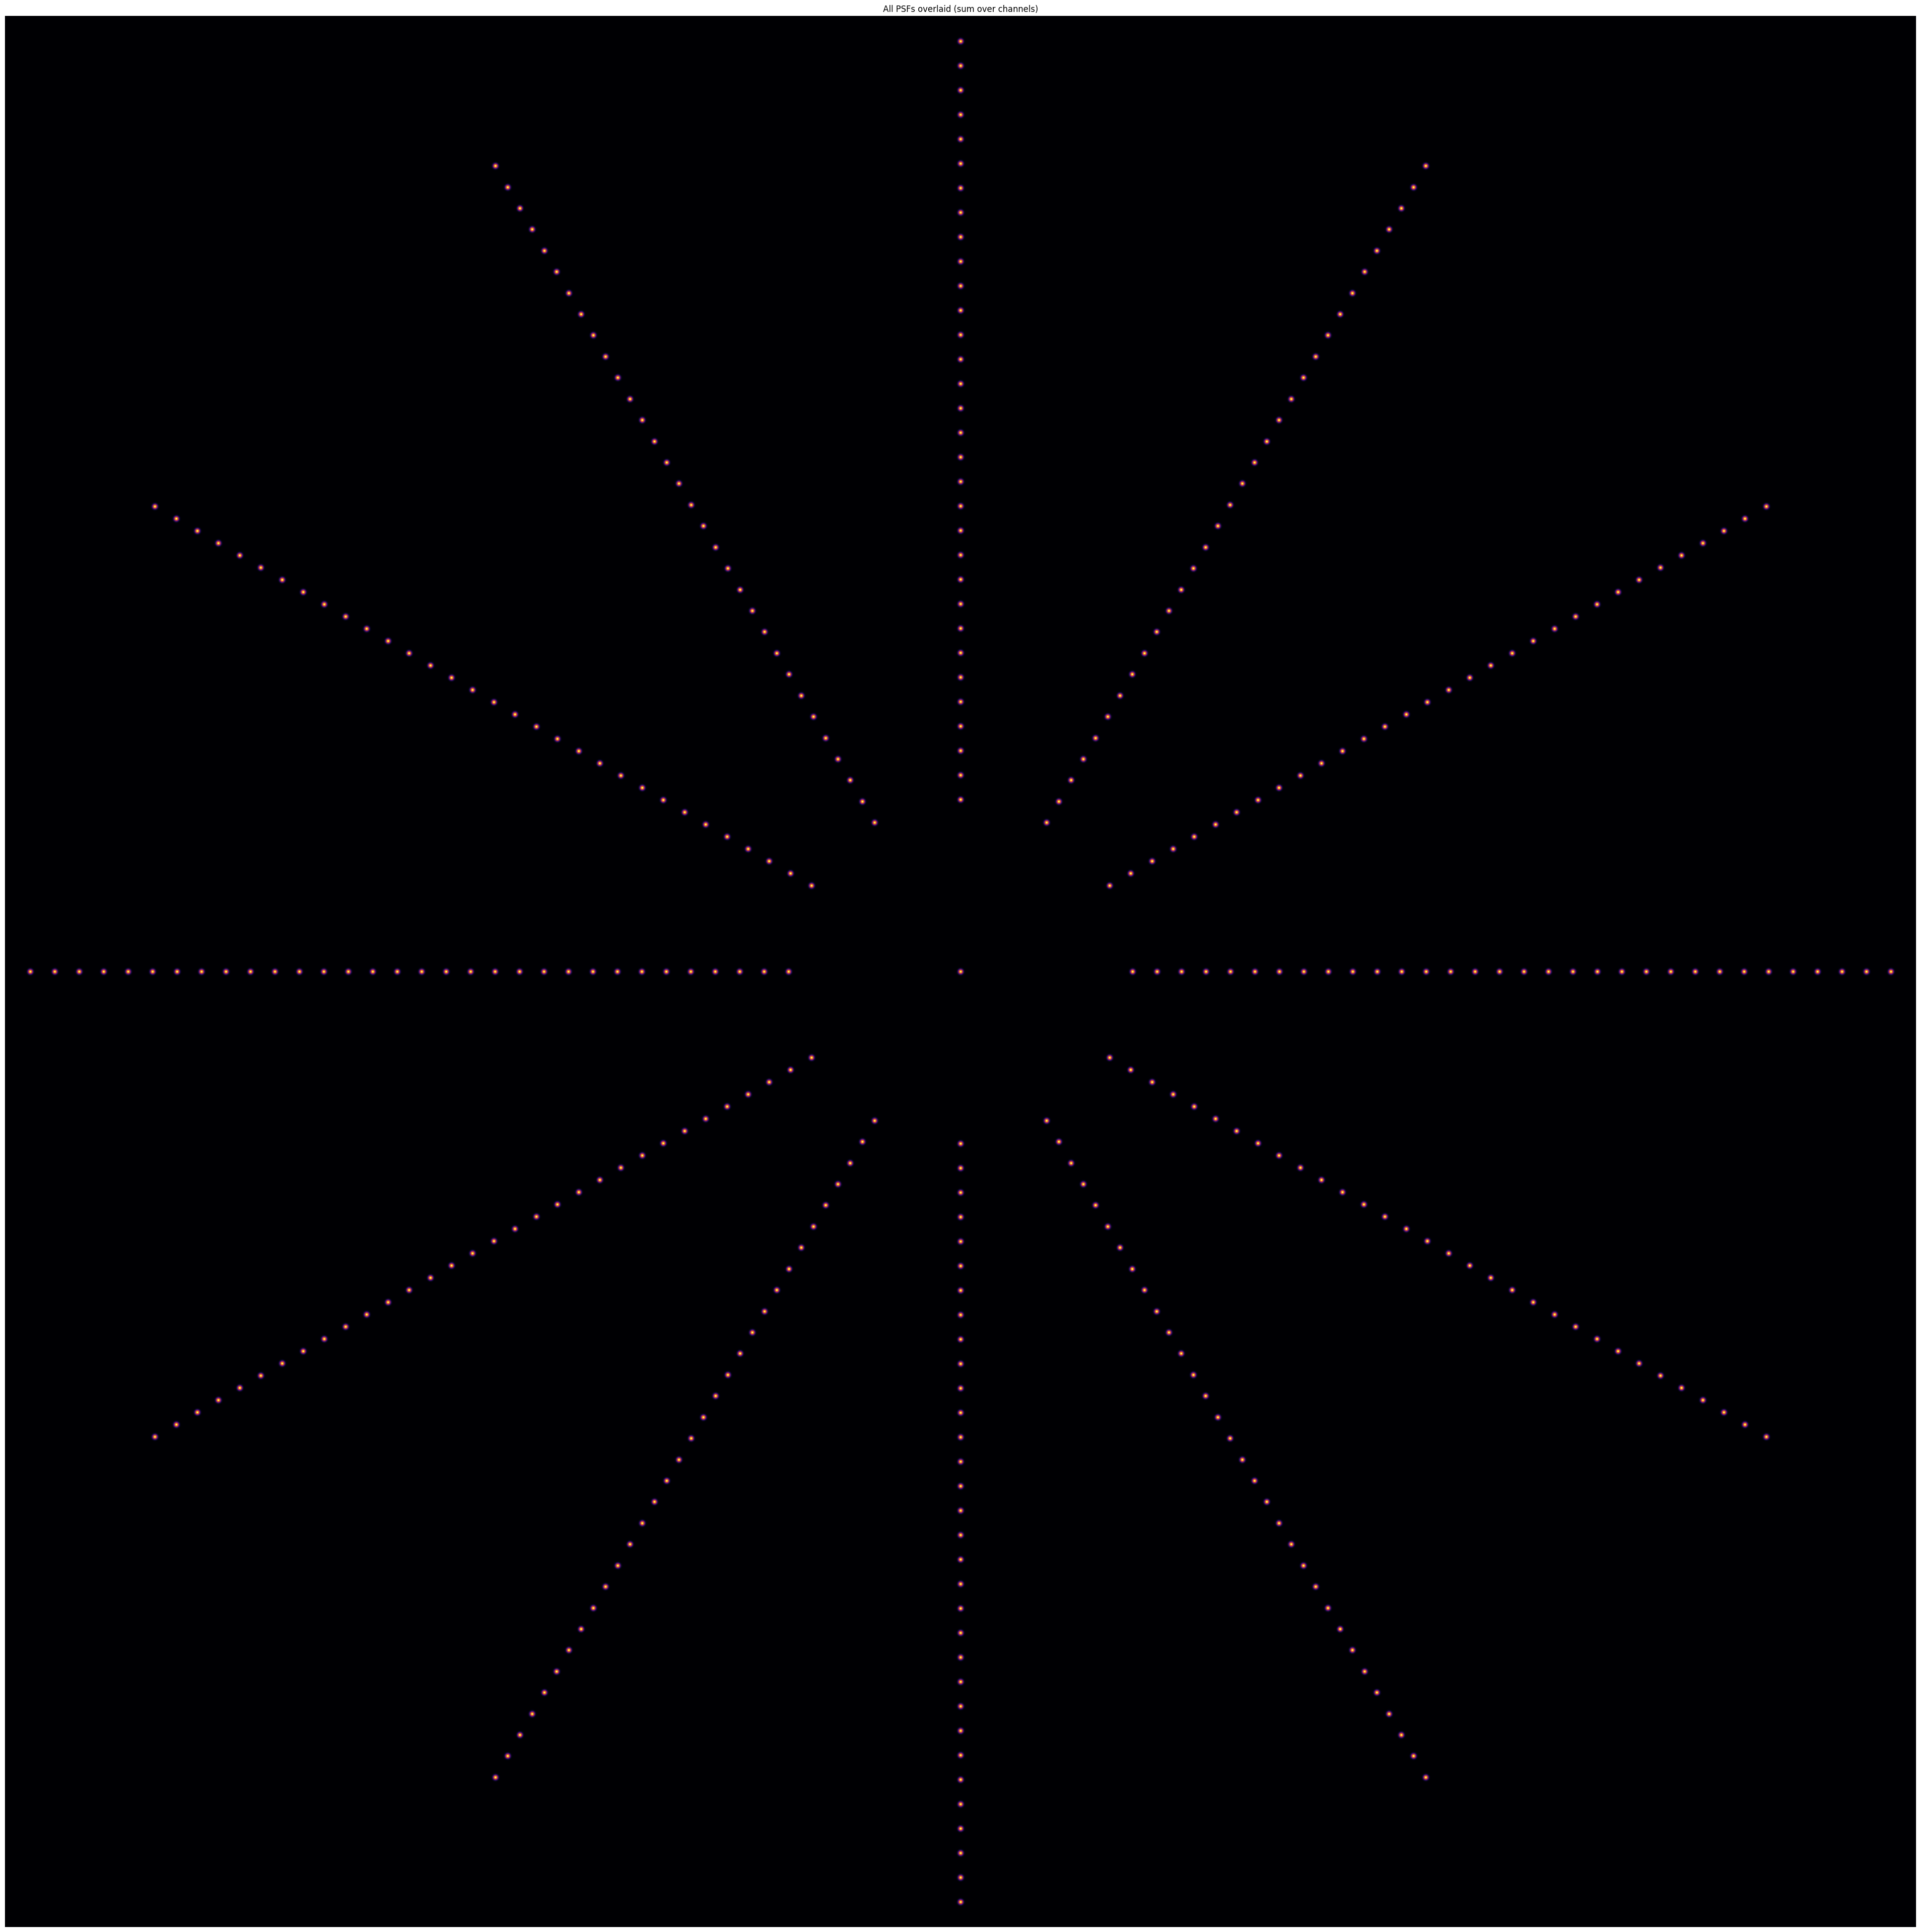

In [ ]:
import numpy as np
import torch
import time
from matplotlib import pyplot as plt
import os

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
FIRST_LAMBDA_CENTER = 450
SHIFT               = 64
N_ORDERS            = 12
N_BANDS             = 32
PSF_SIGMA           = 4.0
GAUSS_SIGMA_0TH     = 8.0
CANVAS              = 5000

PSF_SAVE_PATH       = '../data/ctis_psf.pt'

os.makedirs('../data', exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════
CENTER = CANVAS // 2
ANGLES = [np.radians(i * 360.0 / N_ORDERS) for i in range(N_ORDERS)]

def gaussian_kernel(sigma: float, truncate: float = 4.0) -> torch.Tensor:
    half = int(np.ceil(truncate * sigma))
    size = 2 * half + 1
    y, x = torch.meshgrid(
        torch.arange(size, dtype=torch.float32) - half,
        torch.arange(size, dtype=torch.float32) - half,
        indexing='ij'
    )
    g = torch.exp(-(x**2 + y**2) / (2.0 * sigma**2))
    return g / g.sum()

def stamp_gaussian(canvas: torch.Tensor, cy: float, cx: float, kernel: torch.Tensor):
    H, W   = canvas.shape
    ph, pw = kernel.shape
    hh, hw = ph // 2, pw // 2
    r0 = int(round(cy)) - hh;  r1 = r0 + ph
    c0 = int(round(cx)) - hw;  c1 = c0 + pw
    dr0, dr1 = max(0, r0), min(H, r1)
    dc0, dc1 = max(0, c0), min(W, c1)
    if dr1 <= dr0 or dc1 <= dc0:
        return
    sr0 = dr0 - r0;  sr1 = sr0 + (dr1 - dr0)
    sc0 = dc0 - c0;  sc1 = sc0 + (dc1 - dc0)
    canvas[dr0:dr1, dc0:dc1] += kernel[sr0:sr1, sc0:sc1]

def spectral_gaussian_weights(n_bands: int, sigma: float) -> torch.Tensor:
    mid  = (n_bands - 1) / 2.0
    lams = torch.arange(n_bands, dtype=torch.float32)
    out = torch.exp(-((lams - mid) ** 2) / (2.0 * sigma ** 2))
    return out / out.sum()

# ══════════════════════════════════════════════════════════════════════════════
# BUILD PSF
# ══════════════════════════════════════════════════════════════════════════════
print("Building PSF tensor...")
t0 = time.perf_counter()

kernel   = gaussian_kernel(PSF_SIGMA)
weights0 = spectral_gaussian_weights(N_BANDS, GAUSS_SIGMA_0TH)
print(weights0)
psf      = torch.zeros(N_BANDS, CANVAS, CANVAS, dtype=torch.float32)

for j in range(N_BANDS):
    r = FIRST_LAMBDA_CENTER + SHIFT * j
    for theta in ANGLES:
        cx = r * np.cos(theta) + CENTER
        cy = r * np.sin(theta) + CENTER
        stamp_gaussian(psf[j], cy, cx, kernel)

    stamp_gaussian(psf[j], CENTER, CENTER, kernel * weights0[j].item())

dt = time.perf_counter() - t0
print(f"Peak value : {psf.max():.5f}")

torch.save(psf, PSF_SAVE_PATH)

# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZE ONE PSF (ONE SPOT, ZOOMED)
# ══════════════════════════════════════════════════════════════════════════════

band_id  = N_BANDS // 2          # pick middle wavelength
theta_id = 0                     # pick one diffraction direction

r = FIRST_LAMBDA_CENTER + SHIFT * band_id
theta = ANGLES[theta_id]

cx = int(r * np.cos(theta) + CENTER)
cy = int(r * np.sin(theta) + CENTER)

# crop around the spot
crop_size = 12
patch = psf[band_id,
            cy - crop_size:cy + crop_size,
            cx - crop_size:cx + crop_size].numpy()

plt.figure(figsize=(5,5))
plt.imshow(patch, cmap='inferno')
plt.title(f"Zoomed PSF (band={band_id}, order={theta_id})")
plt.axis('off')
plt.savefig('../plots/psf_zoomed.png', bbox_inches='tight')
plt.show()
plt.close()

# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZE ALL PSFs ON SAME CANVAS (SUM)
# ══════════════════════════════════════════════════════════════════════════════

psf_sum = psf.sum(dim=0).numpy()

plt.figure(figsize=(50,50), dpi=100)  # 50*100 = 5000 px
plt.imshow(psf_sum, cmap='inferno')
plt.title("All PSFs overlaid (sum over channels)")
plt.axis('off')
plt.savefig('../plots/psf_sum_fullres.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()